In [1]:
# %% 
# # MRI Tissue Segmentation (T1 + Labels)
# 
# Task 1: 2D tissue segmentation (standard K-means, extended K-means, Multi-Otsu)  
# Task 2: Evaluation (Dice + accuracy)  
# Task 3: 3D volume K-means with simple 3D smoothing / majority labelling

# %%

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy import ndimage

from sklearn.cluster import KMeans
from skimage.filters import sobel, threshold_multiotsu

# Fix randomness for reproducibility
np.random.seed(0)


T1 shape   : (362, 434, 10)
Label shape: (362, 434, 10)
Unique GT labels: [0 1 2 3 4 5]


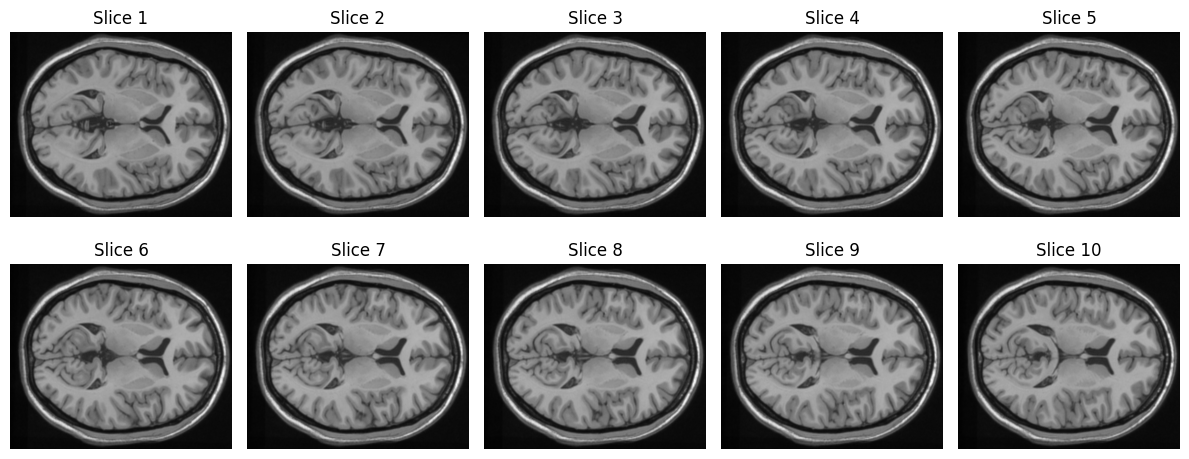

In [2]:
# %%
# ---------------------------
# Load data and basic info
# ---------------------------

data = loadmat("Brain-1.mat")
T1 = data["T1"].astype(np.float32)         # (H, W, 10)
label_gt = data["label"].astype(np.uint8)  # (H, W, 10)

H, W, Z = T1.shape
print("T1 shape   :", T1.shape)
print("Label shape:", label_gt.shape)
print("Unique GT labels:", np.unique(label_gt))

# Quick visual check 
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(Z):
    ax = axes.flat[i]
    ax.imshow(T1[:, :, i], cmap="gray")
    ax.set_title(f"Slice {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()


After normalisation: 0.0 1.0
K=2 centres: [0.50261116 0.09000602]
Initial foreground fraction: 0.5759897650024187
Cleaned foreground fraction: 0.7084979759146575


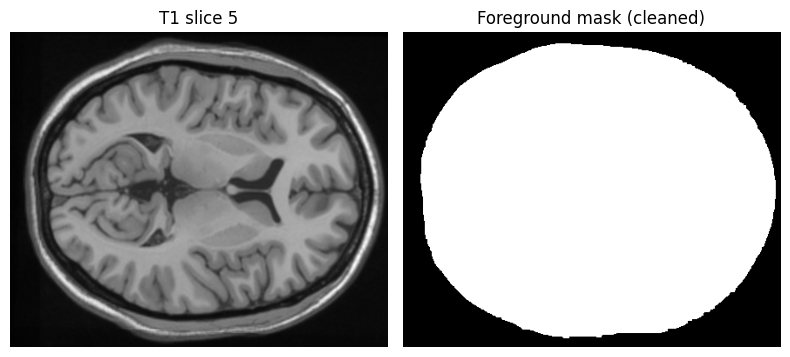

In [3]:
# %%
# --------------------------------
# Global preprocessing / normalise
# --------------------------------
# 1) Contrast stretching via global min-max
# 2) Background mask via K-means (K=2) on intensity only

# Global [0,1] normalisation
t1_min, t1_max = T1.min(), T1.max()
T1_norm = (T1 - t1_min) / (t1_max - t1_min + 1e-8)
print("After normalisation:", T1_norm.min(), T1_norm.max())

# K-means (K=2) on entire volume to get air vs brain
X_all = T1_norm.reshape(-1, 1)
kmeans_bg = KMeans(n_clusters=2, random_state=0, n_init=5, max_iter=150)
kmeans_bg.fit(X_all)

bg_clusters = kmeans_bg.labels_.reshape(H, W, Z)
centers_bg = kmeans_bg.cluster_centers_.flatten()

# cluster with lower mean intensity = air
air_cluster = np.argmin(centers_bg)
fg_mask = bg_clusters != air_cluster   # foreground (labels 1–5)
print("K=2 centres:", centers_bg)
print("Initial foreground fraction:", fg_mask.mean())

# Morphological cleaning per slice (open + close + fill holes + largest component)
for z in range(Z):
    m = fg_mask[:, :, z]
    m = ndimage.binary_opening(m, structure=np.ones((5, 5)))
    m = ndimage.binary_closing(m, structure=np.ones((5, 5)))
    m = ndimage.binary_fill_holes(m)
    lbl, ncc = ndimage.label(m)
    if ncc > 0:
        counts = np.bincount(lbl.ravel())
        # ignore background count at index 0
        largest = np.argmax(counts[1:]) + 1
        m = (lbl == largest)
    fg_mask[:, :, z] = m

bg_mask = ~fg_mask
print("Cleaned foreground fraction:", fg_mask.mean())

# Visualise mask on one slice 
z_show = 4
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(T1_norm[:, :, z_show], cmap="gray")
ax[0].set_title(f"T1 slice {z_show+1}")
ax[0].axis("off")

ax[1].imshow(fg_mask[:, :, z_show], cmap="gray")
ax[1].set_title("Foreground mask (cleaned)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


In [4]:
# %%
# ------------------
# Helper: metrics
# ------------------

def compute_metrics(pred, gt, num_labels=6):
    """
    pred, gt: 3D arrays (H, W, Z) with labels 0..5

    Returns dictionary with:
      - per_dice, per_iou (arrays length num_labels)
      - mean_dice_all (0..5), mean_dice_fg (1..5)
      - mean_iou_all,  mean_iou_fg
      - acc_all  (all voxels, 0..5)
      - acc_fg   (foreground only, gt > 0)
    """
    per_dice = np.zeros(num_labels, dtype=np.float64)
    per_iou = np.zeros(num_labels, dtype=np.float64)

    for lab in range(num_labels):
        g = (gt == lab)
        p = (pred == lab)

        inter = np.logical_and(g, p).sum()
        denom_dice = g.sum() + p.sum()
        union = g.sum() + p.sum() - inter

        per_dice[lab] = 2 * inter / denom_dice if denom_dice > 0 else np.nan
        per_iou[lab] = inter / union if union > 0 else np.nan

    mean_dice_all = np.nanmean(per_dice)
    mean_iou_all = np.nanmean(per_iou)

    per_dice_fg = per_dice.copy()
    per_dice_fg[0] = np.nan
    per_iou_fg = per_iou.copy()
    per_iou_fg[0] = np.nan

    mean_dice_fg = np.nanmean(per_dice_fg)
    mean_iou_fg = np.nanmean(per_iou_fg)

    acc_all = (pred == gt).sum() / gt.size

    fg = gt > 0
    acc_fg = (pred[fg] == gt[fg]).sum() / fg.sum()

    return {
        "per_dice": per_dice,
        "per_iou": per_iou,
        "mean_dice_all": mean_dice_all,
        "mean_dice_fg": mean_dice_fg,
        "mean_iou_all": mean_iou_all,
        "mean_iou_fg": mean_iou_fg,
        "acc_all": acc_all,
        "acc_fg": acc_fg,
    }

In [5]:
# %%
# ------------------------------
# Helper: majority cluster->label
# ------------------------------

def majority_cluster_to_label(cluster_map, gt, fg_mask_slice,
                              valid_labels=(1, 2, 3, 4, 5)):
    """
    cluster_map: 2D array of cluster indices (>= 0) on a single slice
    gt:          GT labels for that slice
    fg_mask_slice: boolean mask of foreground voxels on that slice
    valid_labels: which GT labels are allowed for tissue (exclude air)

    Returns: 2D segmentation with labels 0..5 (0 = air)
    """
    seg = np.zeros_like(gt, dtype=np.uint8)

    clusters = np.unique(cluster_map[fg_mask_slice])
    max_gt = int(gt.max())

    for c in clusters:
        mask_c = (cluster_map == c) & fg_mask_slice
        gt_c = gt[mask_c]
        if gt_c.size == 0:
            continue

        counts = np.bincount(gt_c, minlength=max_gt + 1)
        # keep only counts of tissue labels (1..5)
        valid_mask = np.zeros_like(counts, dtype=bool)
        for l in valid_labels:
            if l < len(valid_mask):
                valid_mask[l] = True

        counts_valid = counts.copy()
        counts_valid[~valid_mask] = 0

        if counts_valid.sum() == 0:
            mapped_label = counts.argmax()
        else:
            mapped_label = counts_valid.argmax()

        seg[mask_c] = mapped_label

    seg[~fg_mask_slice] = 0  # air
    return seg

In [6]:

# %%
# --------------------------
# Helper: Sobel gradients
# --------------------------

def sobel_grad_magnitude(slice_2d):
    gx = sobel(slice_2d, axis=1)  # horizontal
    gy = sobel(slice_2d, axis=0)  # vertical
    mag = np.hypot(gx, gy)
    m_min, m_max = mag.min(), mag.max()
    if m_max > m_min:
        mag = (mag - m_min) / (m_max - m_min)
    else:
        mag = np.zeros_like(mag)
    return mag

# %%
# ===========================================
# METHOD 1: Standard K-means (2D, intensity)
# ===========================================
# - K-means with K=5 on each slice using intensity only
# - Applied on foreground voxels only
# - Cluster->label remapping by majority vote using GT on that slice

def segment_kmeans_2d_intensity(T1_norm, label_gt, fg_mask, n_clusters=5):
    H, W, Z = T1_norm.shape
    seg = np.zeros_like(label_gt, dtype=np.uint8)

    for z in range(Z):
        img = T1_norm[:, :, z]
        gt_z = label_gt[:, :, z]
        fg_z = fg_mask[:, :, z]

        X = img[fg_z].reshape(-1, 1)
        if X.size == 0:
            continue

        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=0,
            n_init=5,
            max_iter=150,
        )
        kmeans.fit(X)
        cluster_fg = kmeans.labels_

        cl_map = np.full_like(gt_z, fill_value=-1, dtype=int)
        cl_map[fg_z] = cluster_fg

        seg[:, :, z] = majority_cluster_to_label(
            cl_map, gt_z, fg_z, valid_labels=(1, 2, 3, 4, 5)
        )

    return seg


seg_std_k = segment_kmeans_2d_intensity(T1_norm, label_gt, fg_mask, n_clusters=5)
metrics_std = compute_metrics(seg_std_k, label_gt)

print("=== Standard K-means 2D (intensity only, K=5) ===")
print("Per-class Dice (0..5):", np.round(metrics_std["per_dice"], 4))
print("Mean Dice 0–5:", np.round(metrics_std["mean_dice_all"], 4))
print("Mean Dice 1–5:", np.round(metrics_std["mean_dice_fg"], 4))
print("Accuracy 0–5:", np.round(metrics_std["acc_all"] * 100, 2), "%")
print("Accuracy 1–5 (GT>0):", np.round(metrics_std["acc_fg"] * 100, 2), "%")

=== Standard K-means 2D (intensity only, K=5) ===
Per-class Dice (0..5): [0.9649 0.2922 0.7518 0.3383 0.813  0.9195]
Mean Dice 0–5: 0.6799
Mean Dice 1–5: 0.6229
Accuracy 0–5: 78.93 %
Accuracy 1–5 (GT>0): 71.06 %


In [7]:
# %%
# ============================================
# METHOD 2: Multi-Otsu thresholding (2D, FG)
# ============================================

def segment_multi_otsu_2d(T1_norm, label_gt, fg_mask, n_classes=5):
    H, W, Z = T1_norm.shape
    seg = np.zeros_like(label_gt, dtype=np.uint8)

    for z in range(Z):
        img = T1_norm[:, :, z]
        gt_z = label_gt[:, :, z]
        fg_z = fg_mask[:, :, z]

        if not fg_z.any():
            continue

        thresholds = threshold_multiotsu(img[fg_z], classes=n_classes)
        cl_full = np.digitize(img, bins=thresholds)

        seg[:, :, z] = majority_cluster_to_label(
            cl_full, gt_z, fg_z, valid_labels=(1, 2, 3, 4, 5)
        )

    return seg


seg_otsu = segment_multi_otsu_2d(T1_norm, label_gt, fg_mask, n_classes=5)
metrics_otsu = compute_metrics(seg_otsu, label_gt)

print("=== Multi-Otsu 2D (classes=5, FG only) ===")
print("Per-class Dice (0..5):", np.round(metrics_otsu["per_dice"], 4))
print("Mean Dice 0–5:", np.round(metrics_otsu["mean_dice_all"], 4))
print("Mean Dice 1–5:", np.round(metrics_otsu["mean_dice_fg"], 4))
print("Accuracy 0–5:", np.round(metrics_otsu["acc_all"] * 100, 2), "%")
print("Accuracy 1–5 (GT>0):", np.round(metrics_otsu["acc_fg"] * 100, 2), "%")

=== Multi-Otsu 2D (classes=5, FG only) ===
Per-class Dice (0..5): [0.9649 0.275  0.7509 0.386  0.8271 0.9428]
Mean Dice 0–5: 0.6911
Mean Dice 1–5: 0.6364
Accuracy 0–5: 79.83 %
Accuracy 1–5 (GT>0): 72.3 %


In [8]:
# ==============================================
# METHOD 3: Extended K-means (2D, intensity+grad)
# ==============================================
# - Feature = [intensity, α * Sobel gradient magnitude]
# - Grid search:
#     * K in {5, 6, 7, 8}
#     * α in {0.1, 0.2, 0.3, 0.5, 0.7}
# - Prefer combos where:
#     Dice1–5 >= Multi-Otsu Dice1–5  AND  Acc1–5 >= Multi-Otsu Acc1–5
# - If none satisfy both, fall back to best combined score:
#     score = 0.7 * Dice1–5 + 0.3 * Acc1–5 special

ALPHA_LIST = [0.1, 0.2, 0.3, 0.5, 0.7]
K_CANDIDATES = [5, 6, 7, 8]

# >>> Multi-Otsu scores from the previous method <<<
metrics_otsu = compute_metrics(seg_otsu, label_gt)
BASE_DICE_FG = metrics_otsu["mean_dice_fg"]
BASE_ACC_FG  = metrics_otsu["acc_fg"]

def segment_kmeans_2d_extended_for_params(
    T1_norm, label_gt, fg_mask, n_clusters, alpha_grad
):
    H, W, Z = T1_norm.shape
    seg = np.zeros_like(label_gt, dtype=np.uint8)

    for z in range(Z):
        img = T1_norm[:, :, z]
        gt_z = label_gt[:, :, z]
        fg_z = fg_mask[:, :, z]

        if not fg_z.any():
            continue

        grad = sobel_grad_magnitude(img)
        X = np.stack([img[fg_z], alpha_grad * grad[fg_z]], axis=1)

        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=0,
            n_init=5,
            max_iter=150,
        )
        kmeans.fit(X)
        cluster_fg = kmeans.labels_

        cl_map = np.full_like(gt_z, fill_value=-1, dtype=int)
        cl_map[fg_z] = cluster_fg

        seg[:, :, z] = majority_cluster_to_label(
            cl_map, gt_z, fg_z, valid_labels=(1, 2, 3, 4, 5)
        )

    return seg


def tune_extended_kmeans_grid(T1_norm, label_gt, fg_mask,
                              k_list, alpha_list,
                              base_dice_fg, base_acc_fg):
    best_score_overall = -1.0
    best_seg_overall = None
    best_metrics_overall = None
    best_k_overall = None
    best_alpha_overall = None

    # "Dominating" = beats Multi-Otsu on both Dice and Acc
    best_score_dom = -1.0
    best_seg_dom = None
    best_metrics_dom = None
    best_k_dom = None
    best_alpha_dom = None

    print("=== Extended K-means grid search (intensity + scaled Sobel) ===")
    print(f"Target (Multi-Otsu baseline): Dice1–5 >= {base_dice_fg:.3f}, "
          f"Acc1–5 >= {base_acc_fg*100:.2f}%\n")

    for alpha in alpha_list:
        for K in k_list:
            seg_k = segment_kmeans_2d_extended_for_params(
                T1_norm, label_gt, fg_mask,
                n_clusters=K, alpha_grad=alpha
            )
            metrics_k = compute_metrics(seg_k, label_gt)

            dice_fg = metrics_k["mean_dice_fg"]
            acc_fg = metrics_k["acc_fg"]
            score = 0.7 * dice_fg + 0.3 * acc_fg

            print(
                f"alpha={alpha:0.2f}, K={K}: "
                f"Dice1–5={dice_fg:.3f}, Acc1–5={acc_fg*100:5.2f}%, "
                f"score={score:.4f}"
            )

            # Track best overall (for fallback)
            if score > best_score_overall:
                best_score_overall = score
                best_seg_overall = seg_k
                best_metrics_overall = metrics_k
                best_k_overall = K
                best_alpha_overall = alpha

            # Check if this combo dominates the Multi-Otsu baseline
            if (dice_fg >= base_dice_fg) and (acc_fg >= base_acc_fg):
                if score > best_score_dom:
                    best_score_dom = score
                    best_seg_dom = seg_k
                    best_metrics_dom = metrics_k
                    best_k_dom = K
                    best_alpha_dom = alpha

    print("\n=== Extended K-means selection ===")
    if best_seg_dom is not None:
        print("Found parameters that beat Multi-Otsu on BOTH Dice1–5 and Acc1–5.")
        print(
            f"Chosen (dominating) params: alpha={best_alpha_dom:.2f}, K={best_k_dom}, "
            f"score={best_score_dom:.4f}"
        )
        print(
            f"Dice1–5={best_metrics_dom['mean_dice_fg']:.3f}, "
            f"Acc1–5={best_metrics_dom['acc_fg']*100:5.2f}%"
        )
        return best_seg_dom, best_metrics_dom, best_k_dom, best_alpha_dom
    else:
        print("No (K, alpha) combo beats Multi-Otsu on BOTH metrics.")
        print("Falling back to best combined score across all candidates.")
        print(
            f"Chosen params: alpha={best_alpha_overall:.2f}, K={best_k_overall}, "
            f"score={best_score_overall:.4f}"
        )
        print(
            f"Dice1–5={best_metrics_overall['mean_dice_fg']:.3f}, "
            f"Acc1–5={best_metrics_overall['acc_fg']*100:5.2f}%"
        )
        return best_seg_overall, best_metrics_overall, best_k_overall, best_alpha_overall


# Run tuning
seg_ext_k, metrics_ext, K_EXT, ALPHA_BEST = tune_extended_kmeans_grid(
    T1_norm, label_gt, fg_mask,
    k_list=K_CANDIDATES,
    alpha_list=ALPHA_LIST,
    base_dice_fg=BASE_DICE_FG,
    base_acc_fg=BASE_ACC_FG,
)

print("\n=== Extended K-means 2D (FINAL) ===")
print(f"Using K={K_EXT}, alpha_grad={ALPHA_BEST:.2f}")
print("Per-class Dice (0..5):", np.round(metrics_ext["per_dice"], 4))
print("Mean Dice 0–5:", np.round(metrics_ext["mean_dice_all"], 4))
print("Mean Dice 1–5:", np.round(metrics_ext["mean_dice_fg"], 4))
print("Accuracy 0–5:", np.round(metrics_ext["acc_all"] * 100, 2), "%")
print("Accuracy 1–5 (GT>0):", np.round(metrics_ext["acc_fg"] * 100, 2), "%")


=== Extended K-means grid search (intensity + scaled Sobel) ===
Target (Multi-Otsu baseline): Dice1–5 >= 0.636, Acc1–5 >= 72.30%

alpha=0.10, K=5: Dice1–5=0.637, Acc1–5=72.56%, score=0.6634
alpha=0.10, K=6: Dice1–5=0.628, Acc1–5=69.29%, score=0.6476
alpha=0.10, K=7: Dice1–5=0.680, Acc1–5=69.75%, score=0.6850
alpha=0.10, K=8: Dice1–5=0.705, Acc1–5=73.89%, score=0.7151
alpha=0.20, K=5: Dice1–5=0.633, Acc1–5=72.68%, score=0.6611
alpha=0.20, K=6: Dice1–5=0.656, Acc1–5=72.26%, score=0.6761
alpha=0.20, K=7: Dice1–5=0.670, Acc1–5=69.85%, score=0.6786
alpha=0.20, K=8: Dice1–5=0.708, Acc1–5=73.17%, score=0.7148
alpha=0.30, K=5: Dice1–5=0.627, Acc1–5=73.34%, score=0.6590
alpha=0.30, K=6: Dice1–5=0.697, Acc1–5=75.97%, score=0.7160
alpha=0.30, K=7: Dice1–5=0.699, Acc1–5=74.35%, score=0.7124
alpha=0.30, K=8: Dice1–5=0.705, Acc1–5=72.27%, score=0.7102
alpha=0.50, K=5: Dice1–5=0.606, Acc1–5=74.12%, score=0.6467
alpha=0.50, K=6: Dice1–5=0.664, Acc1–5=75.53%, score=0.6916
alpha=0.50, K=7: Dice1–5=0.694

In [9]:
# %%
# =====================================
# METHOD 4: 3D K-means on full volume
# =====================================
# - Work on 3D volume as one set of voxels
# - K-means on intensity only (foreground voxels)
# - Elbow to choose K (5–8)
# - Cluster->label remapping (majority)
# - 3D majority filter (3x3x3) as simple smoothing

def segment_kmeans_3d_volume(T1_norm, label_gt, fg_mask,
                             k_min=5, k_max=8, smoothing_size=3):
    H, W, Z = T1_norm.shape

    X_fg = T1_norm[fg_mask].reshape(-1, 1)

    Ks = list(range(k_min, k_max + 1))
    inertias = []
    for K in Ks:
        km = KMeans(n_clusters=K, random_state=0, n_init=3, max_iter=120)
        km.fit(X_fg)
        inertias.append(km.inertia_)
    inertias = np.array(inertias)

    diffs = -np.diff(inertias)
    best_idx = np.argmax(diffs)
    k_opt_3d = Ks[best_idx]

    print("3D K-means elbow Ks:", Ks)
    print("3D K-means inertias:", np.round(inertias, 2))
    print("Chosen K for 3D volume:", k_opt_3d)

    kmeans = KMeans(
        n_clusters=k_opt_3d,
        random_state=0,
        n_init=5,
        max_iter=200,
    )
    kmeans.fit(X_fg)
    cluster_fg = kmeans.labels_

    cl_3d = np.full((H, W, Z), fill_value=-1, dtype=int)
    cl_3d[fg_mask] = cluster_fg

    seg_3d = np.zeros_like(label_gt, dtype=np.uint8)
    for z in range(Z):
        cl_z = cl_3d[:, :, z]
        gt_z = label_gt[:, :, z]
        fg_z = fg_mask[:, :, z]
        seg_3d[:, :, z] = majority_cluster_to_label(
            cl_z, gt_z, fg_z, valid_labels=(1, 2, 3, 4, 5)
        )

    # 3D majority smoothing
    if smoothing_size is not None and smoothing_size > 1:
        def majority_func(vals):
            vals = vals.astype(int)
            counts = np.bincount(vals)
            return np.argmax(counts)

        seg_smooth = ndimage.generic_filter(
            seg_3d,
            function=majority_func,
            size=(smoothing_size, smoothing_size, smoothing_size),
            mode="nearest"
        ).astype(np.uint8)
    else:
        seg_smooth = seg_3d

    return seg_3d, seg_smooth, k_opt_3d


seg_3d_raw, seg_3d_smooth, k_opt_3d = segment_kmeans_3d_volume(
    T1_norm, label_gt, fg_mask,
    k_min=5, k_max=8, smoothing_size=3
)
metrics_3d = compute_metrics(seg_3d_smooth, label_gt)

print("=== 3D K-means volume (intensity, K={}) ===".format(k_opt_3d))
print("Per-class Dice (0..5):", np.round(metrics_3d["per_dice"], 4))
print("Mean Dice 0–5:", np.round(metrics_3d["mean_dice_all"], 4))
print("Mean Dice 1–5:", np.round(metrics_3d["mean_dice_fg"], 4))
print("Accuracy 0–5:", np.round(metrics_3d["acc_all"] * 100, 2), "%")
print("Accuracy 1–5 (GT>0):", np.round(metrics_3d["acc_fg"] * 100, 2), "%")

3D K-means elbow Ks: [5, 6, 7, 8]
3D K-means inertias: [1833.86 1303.1   901.76  701.15]
Chosen K for 3D volume: 5
=== 3D K-means volume (intensity, K=5) ===
Per-class Dice (0..5): [0.9626 0.2892 0.7389 0.3938 0.8358 0.941 ]
Mean Dice 0–5: 0.6935
Mean Dice 1–5: 0.6397
Accuracy 0–5: 80.14 %
Accuracy 1–5 (GT>0): 72.73 %


/tmp/ipykernel_27132/1642129212.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


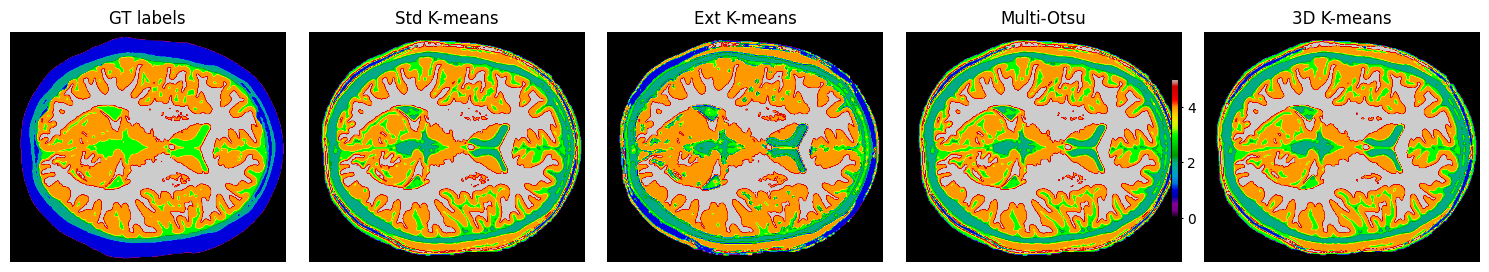

In [10]:
# =========================
# Quick visual comparison
# =========================
z_vis = 4  # picking this slice index to visualise

methods = {
    "GT labels": label_gt[:, :, z_vis],
    "Std K-means": seg_std_k[:, :, z_vis],
    "Ext K-means": seg_ext_k[:, :, z_vis],
    "Multi-Otsu": seg_otsu[:, :, z_vis],
    "3D K-means": seg_3d_smooth[:, :, z_vis],
}

fig, axes = plt.subplots(1, len(methods), figsize=(15, 3))
for ax, (name, img) in zip(axes, methods.items()):
    im = ax.imshow(img, vmin=0, vmax=5, cmap="nipy_spectral")
    ax.set_title(name)
    ax.axis("off")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()


In [11]:
# %%
# =========================
# Print summary table
# =========================
print("\n===== SUMMARY (labels 0–5 and 1–5) =====")
def summary_line(name, m):
    print(
        f"{name:20s} "
        f"Dice0–5: {m['mean_dice_all']:.3f}  "
        f"Dice1–5: {m['mean_dice_fg']:.3f}  "
        f"Acc0–5: {m['acc_all']*100:5.2f}%  "
        f"Acc1–5: {m['acc_fg']*100:5.2f}%"
    )

summary_line("Std K-means 2D",   metrics_std)
summary_line("Ext K-means 2D",   metrics_ext)
summary_line("Multi-Otsu 2D",    metrics_otsu)
summary_line("3D K-means vol",   metrics_3d)


===== SUMMARY (labels 0–5 and 1–5) =====
Std K-means 2D       Dice0–5: 0.680  Dice1–5: 0.623  Acc0–5: 78.93%  Acc1–5: 71.06%
Ext K-means 2D       Dice0–5: 0.755  Dice1–5: 0.713  Acc0–5: 82.18%  Acc1–5: 75.53%
Multi-Otsu 2D        Dice0–5: 0.691  Dice1–5: 0.636  Acc0–5: 79.83%  Acc1–5: 72.30%
3D K-means vol       Dice0–5: 0.694  Dice1–5: 0.640  Acc0–5: 80.14%  Acc1–5: 72.73%
